# discharge data process
This script processes raw discharge data from a hydrometric station and identifies flow events.
Each event is defined by:
- A discharge value exceeding a defined threshold.
- Start: the last time discharge was 0 before the event.
- End: the first time discharge returns to 0 after the event.
Events that occur within a defined gap (e.g., 48 hours) are merged.
The script outputs a table of flow events and plots a hydrograph for each.

# Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns

#  Load and preprocess data 

In [2]:
#  Define Parameters:
flow_threshold = 0.01       # Minimum discharge to define an event (m³/s)
merge_gap_hours = 48        # Max time between events for merging
# time_step_seconds = 5 * 60  # observed intervals = 5 minutes = 300 seconds, uses to compute flow volume

In [3]:
# --- Load and preprocess data ---
discharge_csv_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\discharge\discharge_rakafot_gazelle_1.csv"
raw_data = pd.read_csv(discharge_csv_path)

raw_data['timestamp'] = pd.to_datetime(
    raw_data['Date'] + ' ' + raw_data['Time'],
    dayfirst=True,
    errors='coerce'
)

discharge_data = raw_data[['timestamp', 'Computed Discharge(m³/s)']].copy()
discharge_data.rename(columns={'Computed Discharge(m³/s)': 'discharge_cms'}, inplace=True)
discharge_data.dropna(subset=['timestamp', 'discharge_cms'], inplace=True)
discharge_data.sort_values('timestamp', inplace=True)
discharge_data.reset_index(drop=True, inplace=True)

#  Identify raw events (based on threshold)
discharge_data['above_threshold'] = discharge_data['discharge_cms'] > flow_threshold
discharge_data['shifted'] = discharge_data['above_threshold'].shift(fill_value=False)
discharge_data['new_event'] = discharge_data['above_threshold'] & ~discharge_data['shifted']

event_id = 0
event_ids = []

for is_new, is_above in zip(discharge_data['new_event'], discharge_data['above_threshold']):
    if is_new:
        event_id += 1
    event_ids.append(event_id if is_above else 0)

discharge_data['raw_event_id'] = event_ids

In [4]:
# --- Build raw events ---
events = []

for raw_event_id in discharge_data['raw_event_id'].unique():
    if raw_event_id == 0:
        continue

    event_rows = discharge_data[discharge_data['raw_event_id'] == raw_event_id]
    start_idx = event_rows.index[0]
    end_idx = event_rows.index[-1]

    pre_range = discharge_data.loc[:start_idx - 1]
    pre_zero_idx = pre_range[pre_range['discharge_cms'] == 0].last_valid_index()
    event_start = discharge_data.loc[pre_zero_idx, 'timestamp'] if pre_zero_idx is not None else discharge_data.iloc[0]['timestamp']

    post_range = discharge_data.loc[end_idx + 1:]
    post_zero_idx = post_range[post_range['discharge_cms'] == 0].first_valid_index()
    event_end = discharge_data.loc[post_zero_idx, 'timestamp'] if post_zero_idx is not None else discharge_data.iloc[-1]['timestamp']

    event_data = discharge_data[
        (discharge_data['timestamp'] >= event_start) &
        (discharge_data['timestamp'] <= event_end)
    ]

    
    event_data = event_data.copy()
    event_data['time_diff'] = event_data['timestamp'].diff().dt.total_seconds()
    event_data['time_diff'].fillna(0, inplace=True)  # First point has no diff
    event_data['volume'] = event_data['discharge_cms'] * event_data['time_diff']
    total_volume = event_data['volume'].sum()  # in m³

    
    peak_idx = event_data['discharge_cms'].idxmax()
    peak_time = discharge_data.loc[peak_idx, 'timestamp']
    peak_value = discharge_data.loc[peak_idx, 'discharge_cms']

    events.append({
        'flow_start_date': event_start.date(),
        'flow_start_time': event_start.time(),
        'flow_end_date': event_end.date(),
        'flow_end_time': event_end.time(),
        'flow_total_volume_m3': total_volume,
        'flow_peak_date': peak_time.date(),
        'flow_peak_time': peak_time.time(),
        'flow_peak_m3_s': peak_value
    })

# --- Create event table and remove duplicates ---
raw_events = pd.DataFrame(events).drop_duplicates(subset=['flow_start_date', 'flow_start_time',
                                                           'flow_end_date', 'flow_end_time']).reset_index(drop=True)


#  Merge close events 

In [5]:
from datetime import datetime

# Combine date + time to full timestamp for merging
raw_events['start_ts'] = pd.to_datetime(raw_events['flow_start_date'].astype(str) + ' ' + raw_events['flow_start_time'].astype(str))
raw_events['end_ts'] = pd.to_datetime(raw_events['flow_end_date'].astype(str) + ' ' + raw_events['flow_end_time'].astype(str))

# Sort just in case
raw_events.sort_values('start_ts', inplace=True)
raw_events.reset_index(drop=True, inplace=True)

# Initialize merging
merged_events = []
current = raw_events.iloc[0].copy()

for i in range(1, len(raw_events)):
    next_row = raw_events.iloc[i]
    gap = (next_row['start_ts'] - current['end_ts']).total_seconds() / 3600

    if gap <= merge_gap_hours:
        current['flow_end_date'] = next_row['flow_end_date']
        current['flow_end_time'] = next_row['flow_end_time']
        current['flow_total_volume_m3'] += next_row['flow_total_volume_m3']
        
        if next_row['flow_peak_m3_s'] > current['flow_peak_m3_s']:
            current['flow_peak_m3_s'] = next_row['flow_peak_m3_s']
            current['flow_peak_date'] = next_row['flow_peak_date']
            current['flow_peak_time'] = next_row['flow_peak_time']

        current['end_ts'] = next_row['end_ts']
    else:
        merged_events.append(current)
        current = next_row.copy()

merged_events.append(current)
flow_events = pd.DataFrame(merged_events)

# Drop the helper timestamp columns
flow_events.drop(columns=['start_ts', 'end_ts'], inplace=True)


# Save flow events table to CSV (without index)
output_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\discharge\flow_events_processed.csv"
flow_events.to_csv(output_path, index=False)


#  Plot hydrographs 

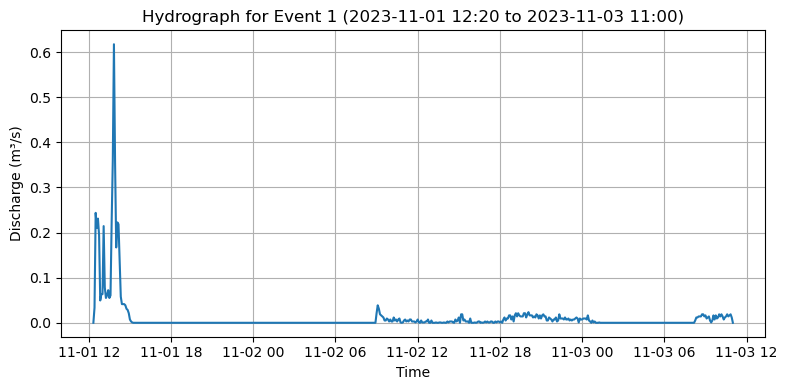

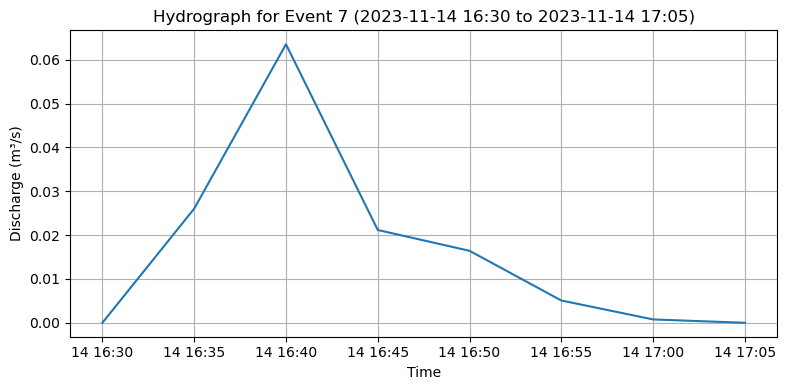

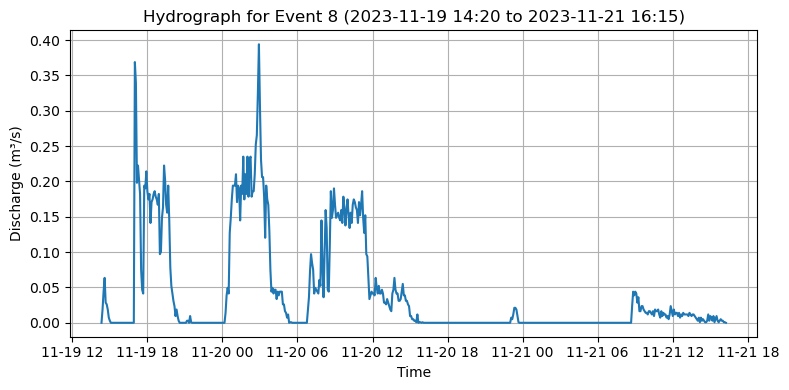

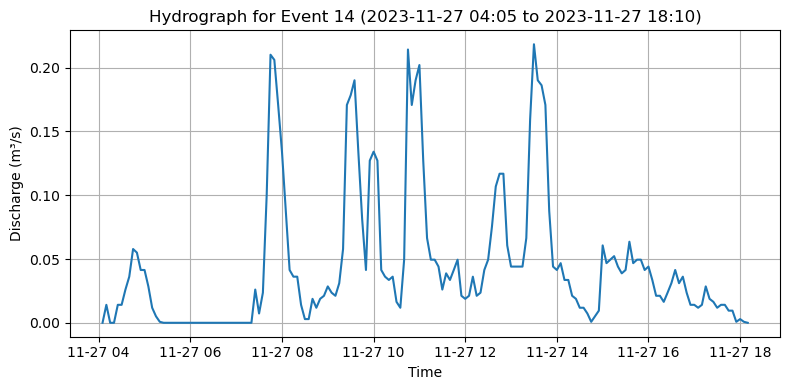

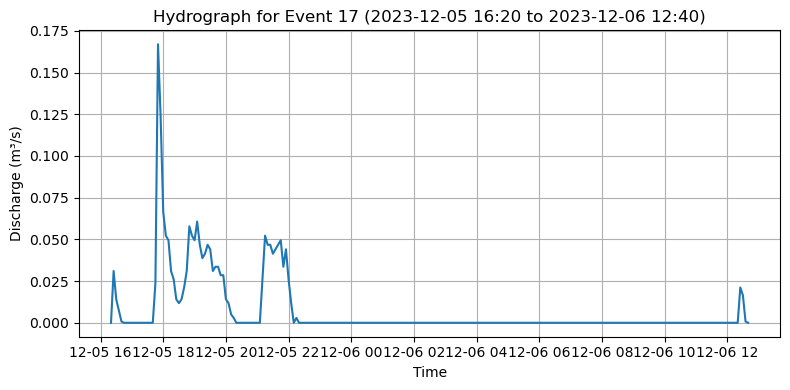

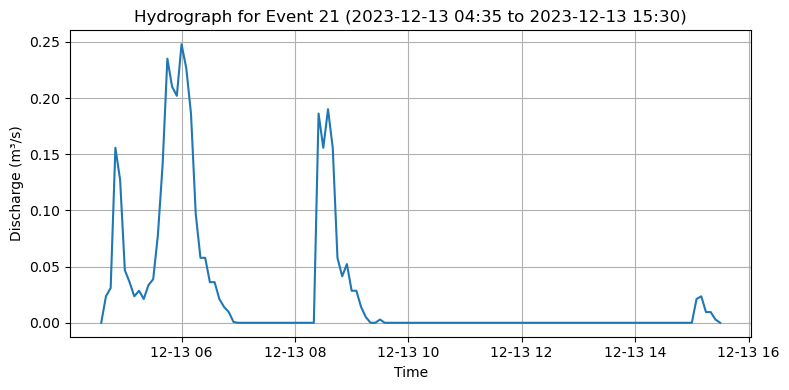

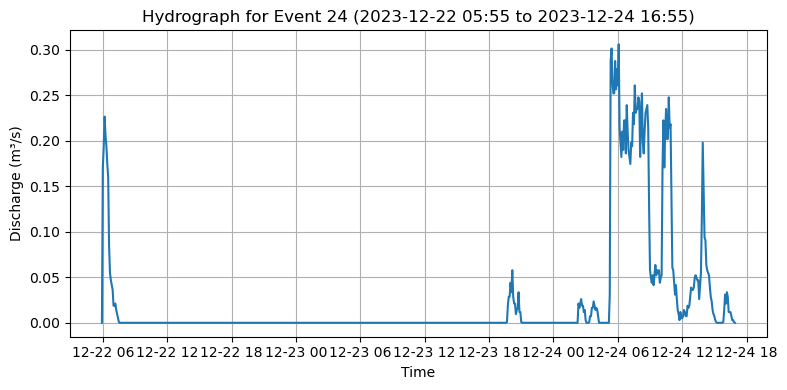

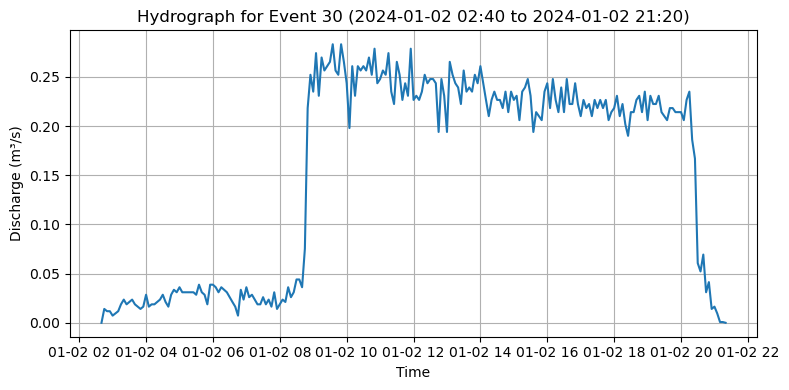

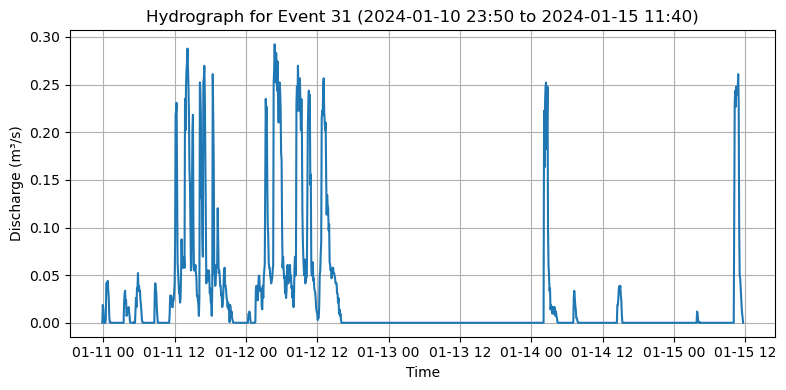

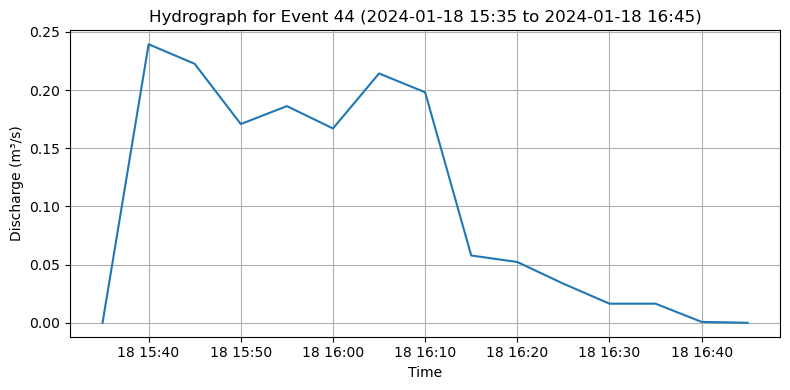

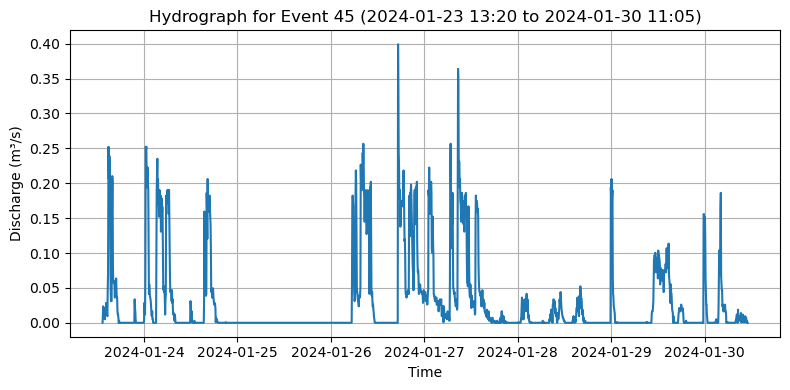

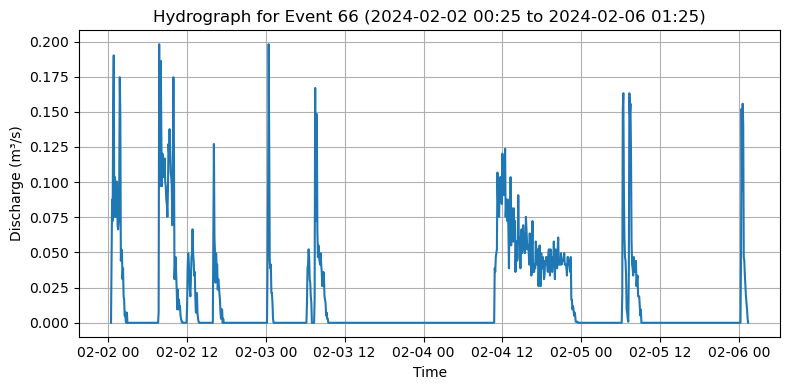

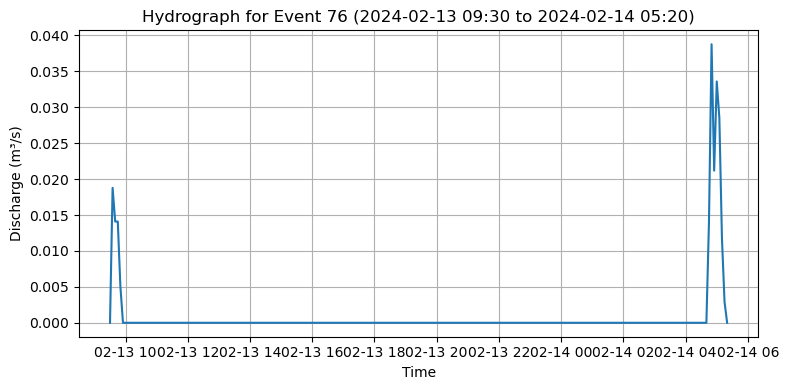

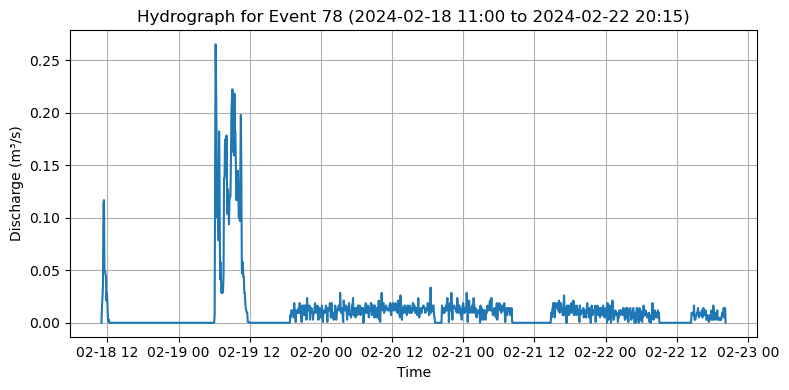

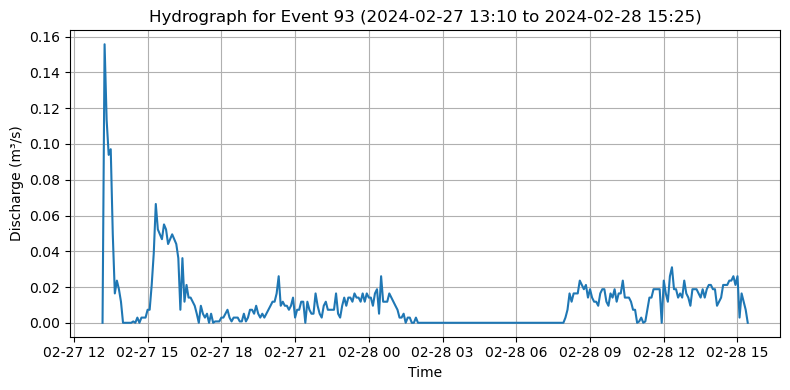

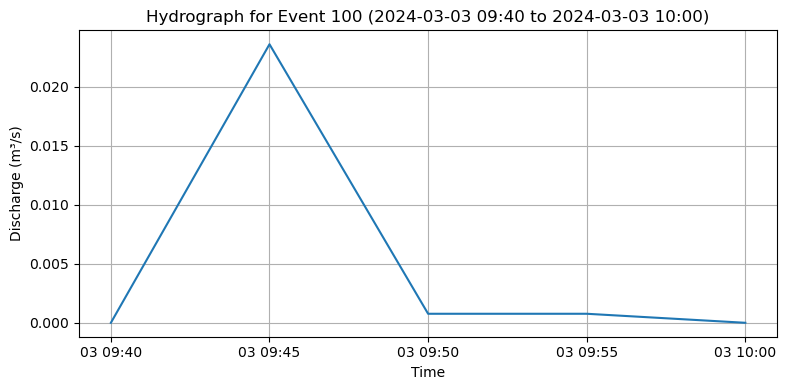

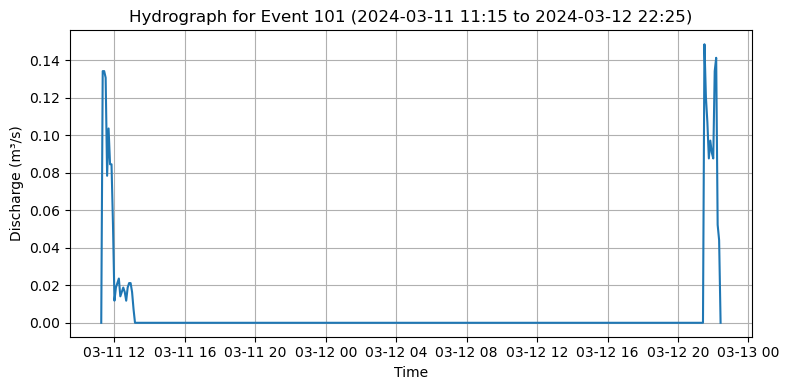

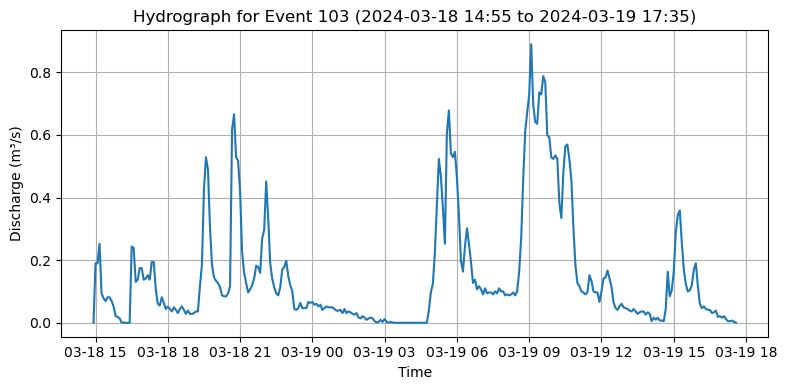

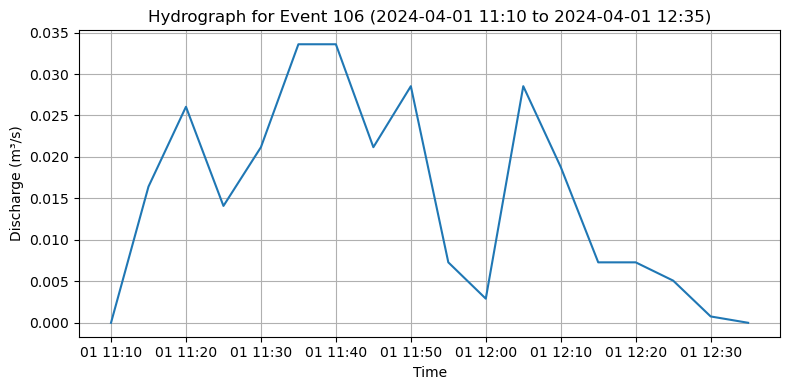

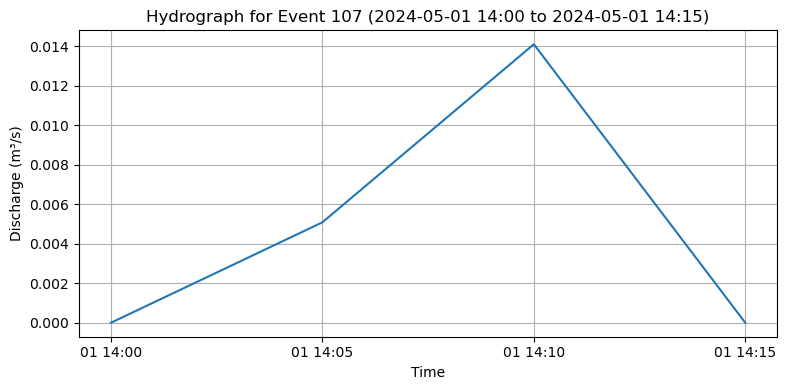

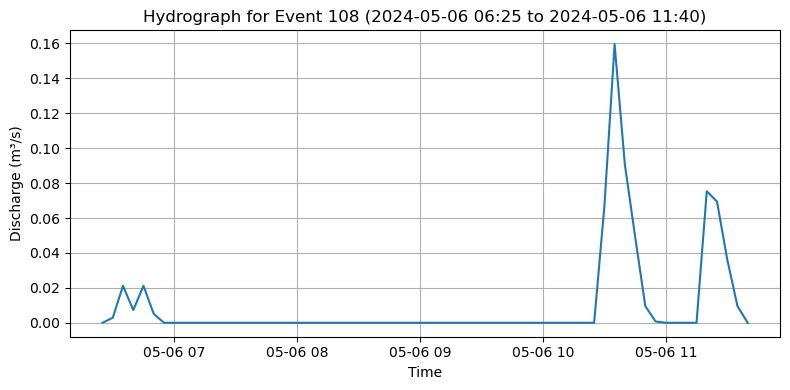

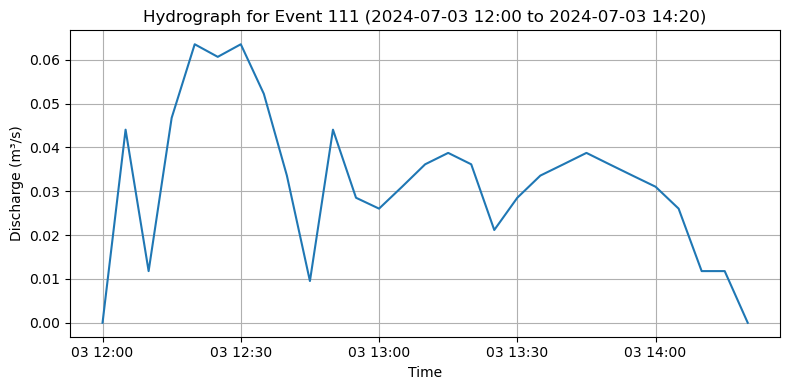

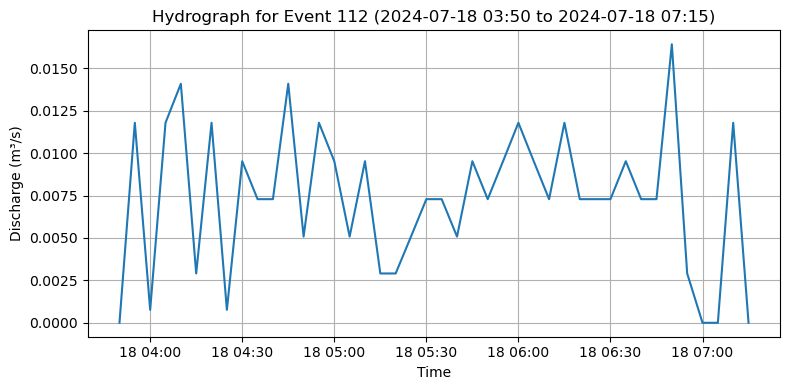

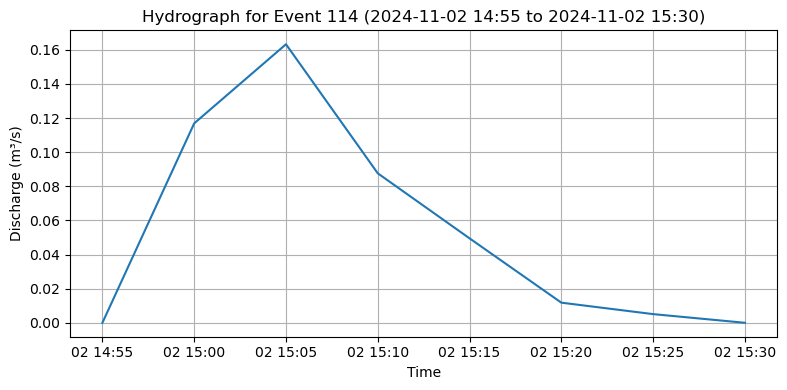

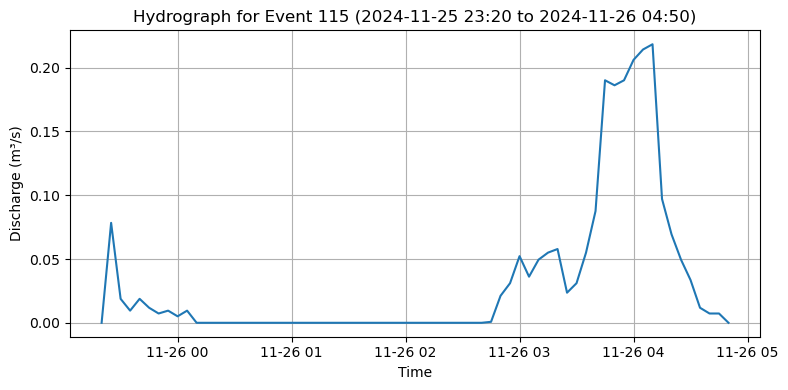

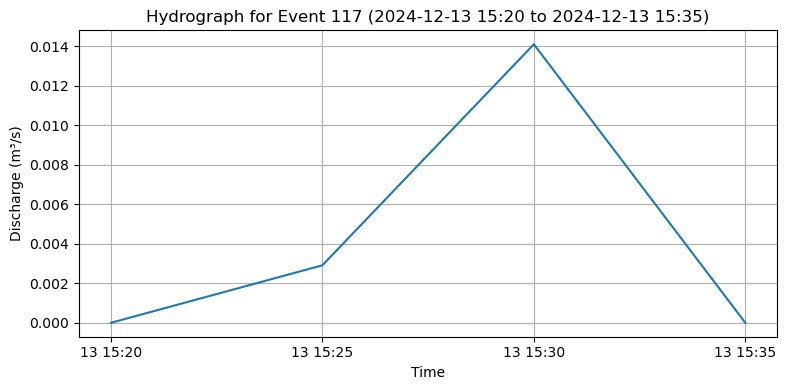

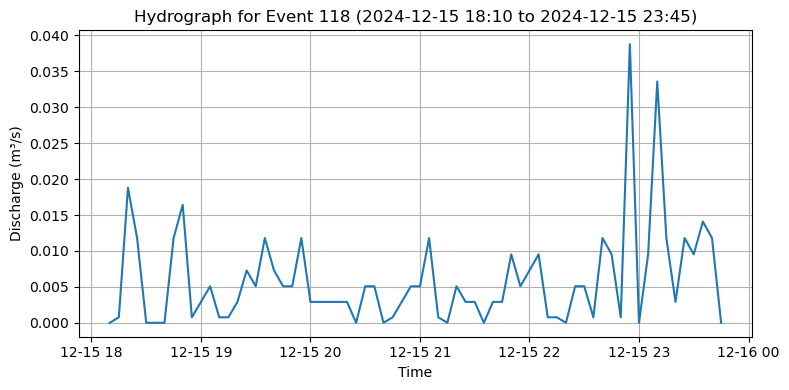

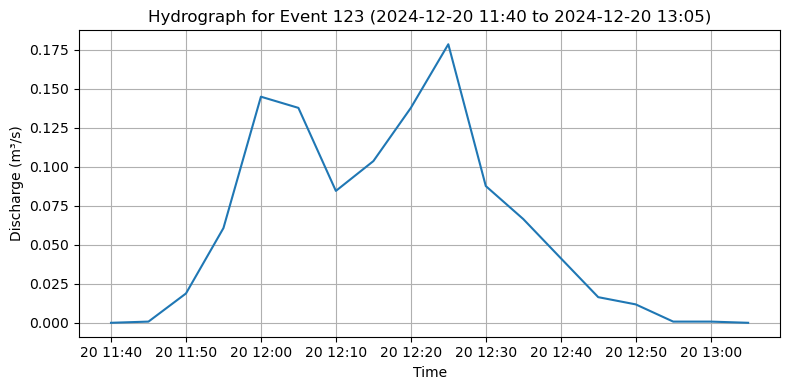

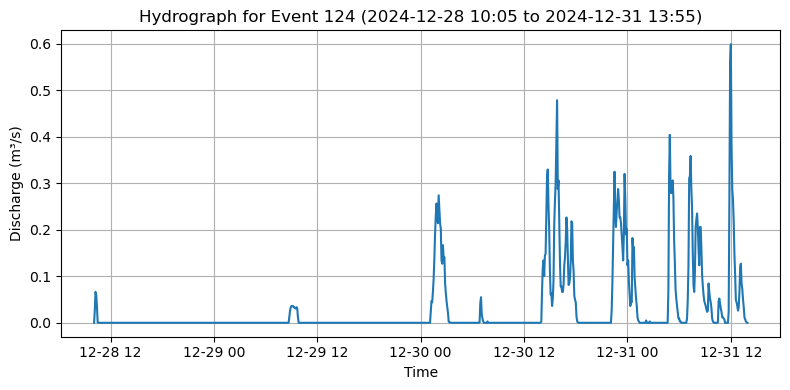

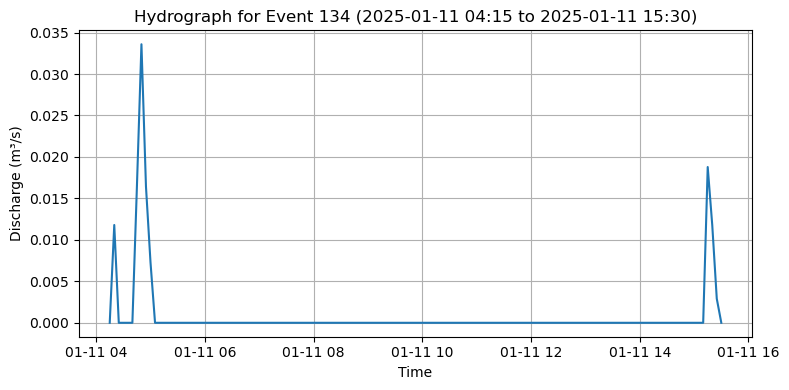

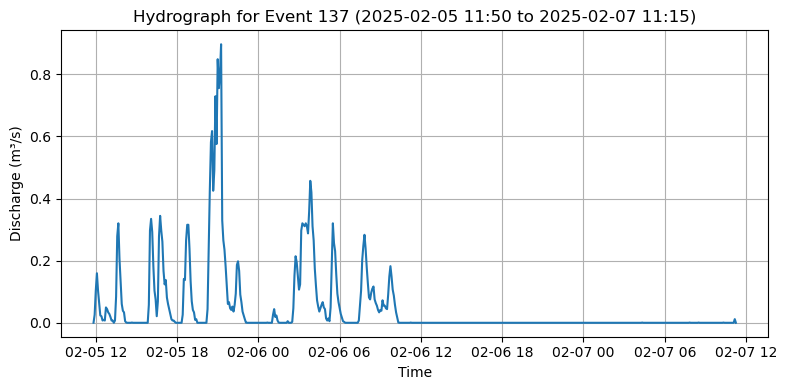

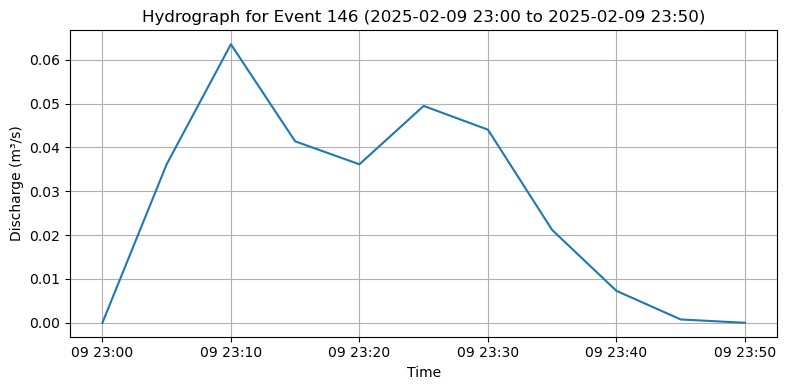

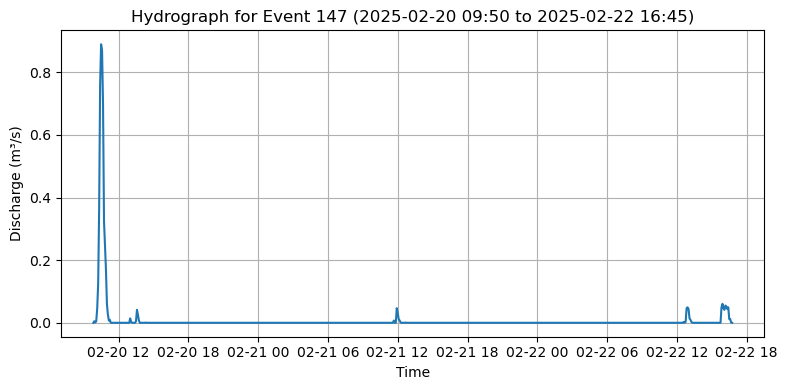

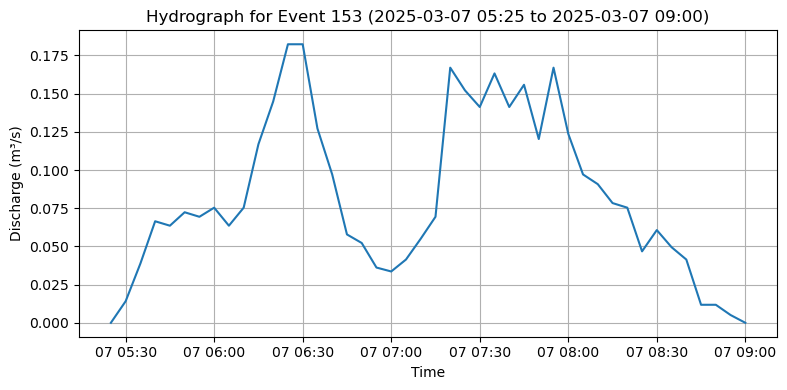

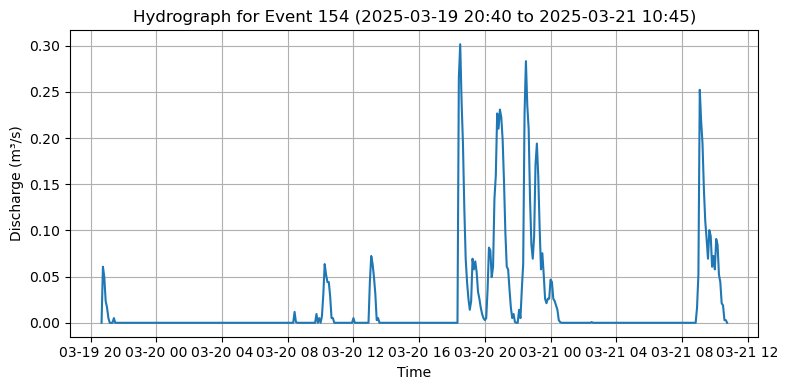

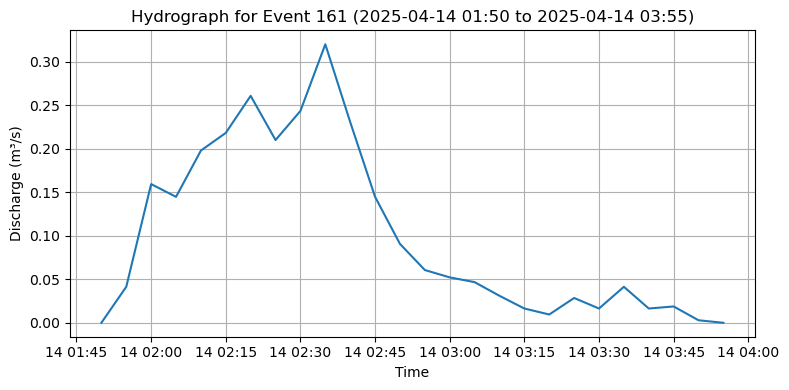

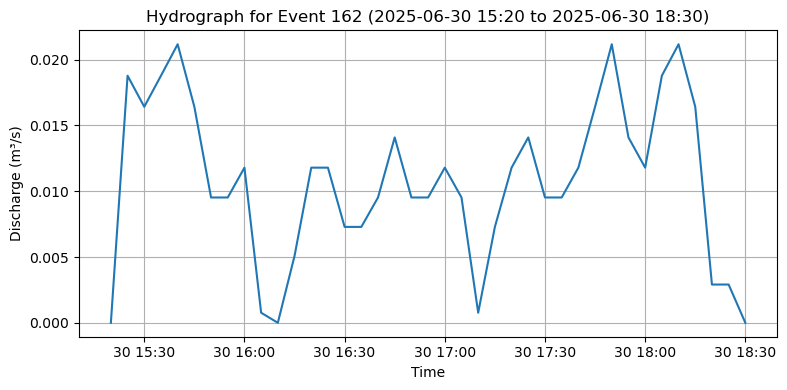

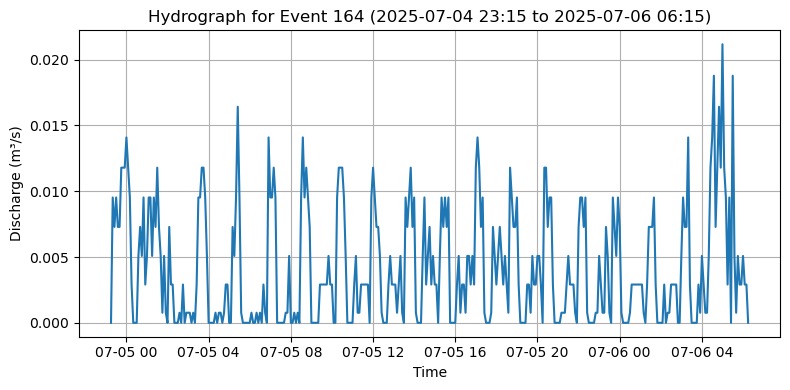

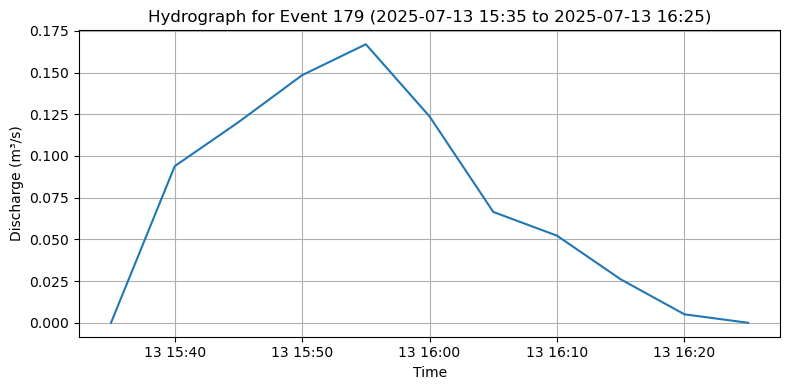

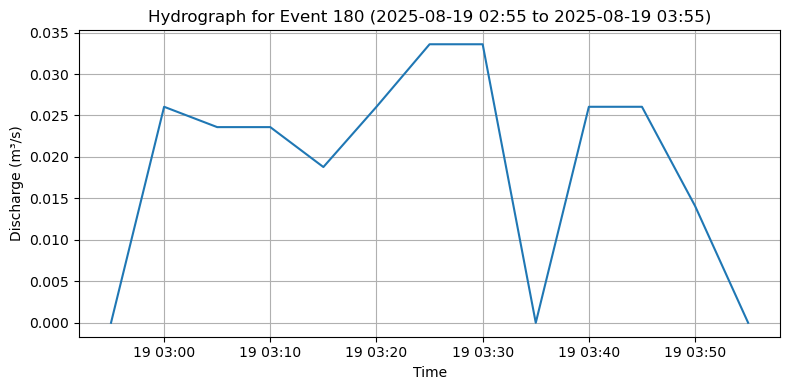

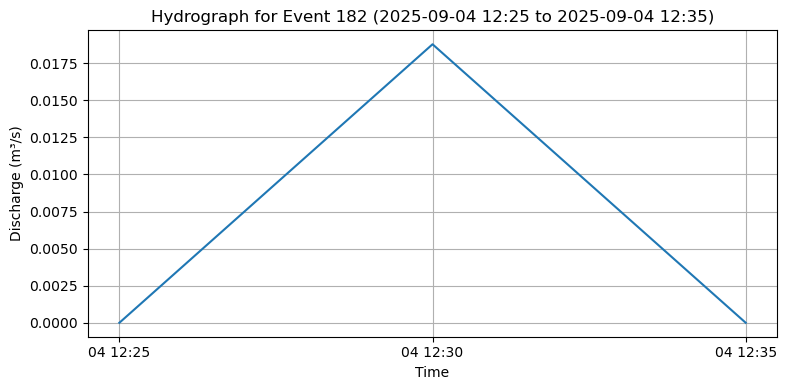

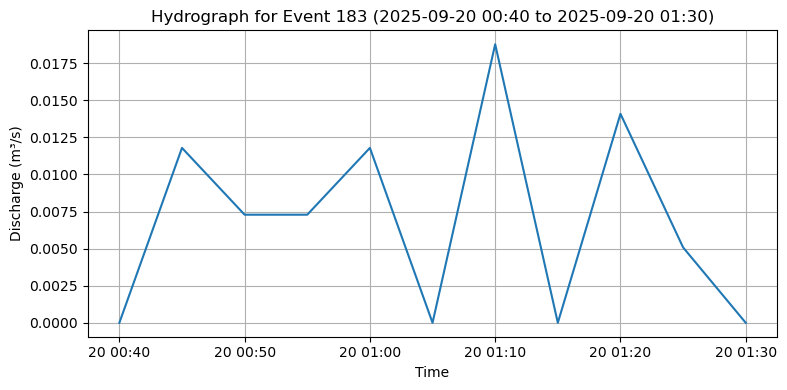

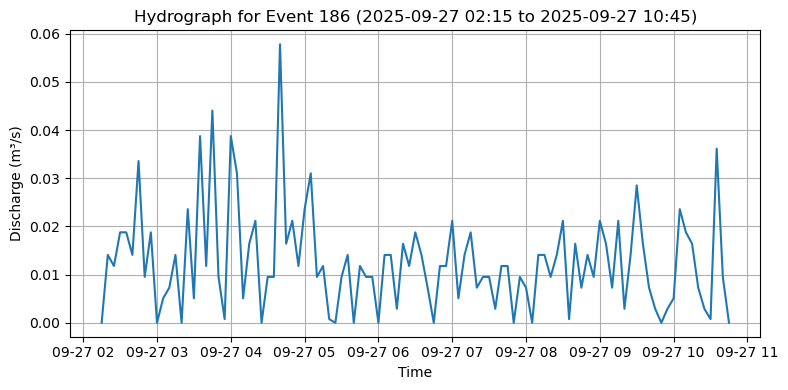

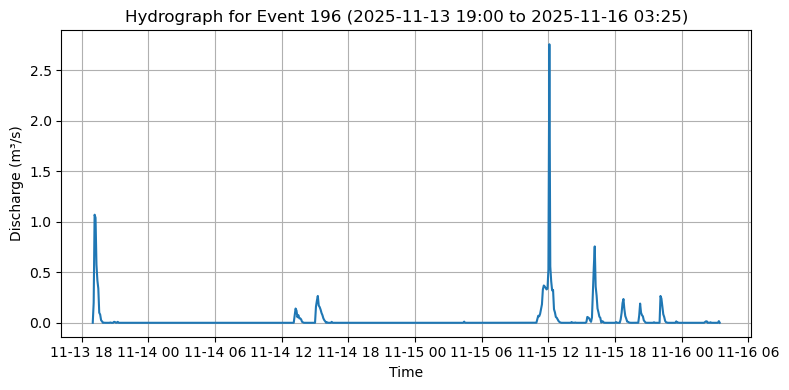

In [6]:
for i, event in flow_events.iterrows():
    # Combine date and time into full timestamps
    start = pd.Timestamp(f"{event['flow_start_date']} {event['flow_start_time']}")
    end = pd.Timestamp(f"{event['flow_end_date']} {event['flow_end_time']}")

    # Extract event data from full discharge dataset
    event_data = discharge_data[
        (discharge_data['timestamp'] >= start) &
        (discharge_data['timestamp'] <= end)
    ]

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(event_data['timestamp'], event_data['discharge_cms'], linestyle='-')
    start_str = start.strftime('%Y-%m-%d %H:%M')
    end_str = end.strftime('%Y-%m-%d %H:%M')
    plt.title(f"Hydrograph for Event {i+1} ({start_str} to {end_str})")
    plt.xlabel("Time")
    plt.ylabel("Discharge (m³/s)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


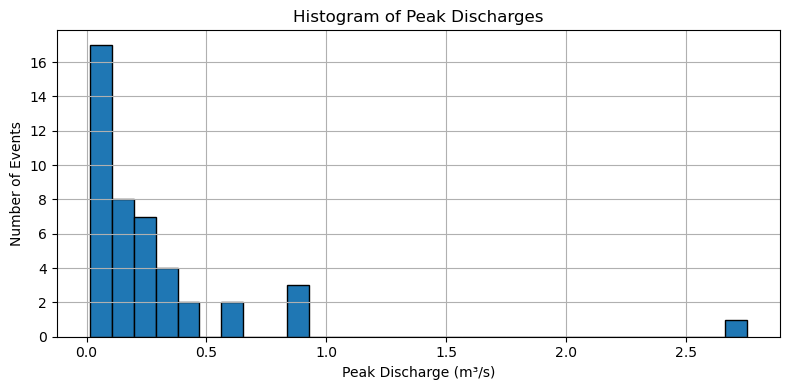

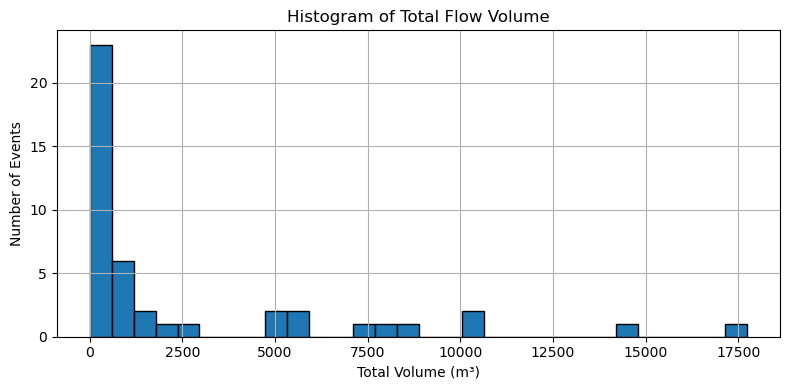

In [7]:
import matplotlib.pyplot as plt

# Histogram of peak discharges
plt.figure(figsize=(8, 4))
plt.hist(flow_events['flow_peak_m3_s'], bins=30, edgecolor='black')
plt.title("Histogram of Peak Discharges")
plt.xlabel("Peak Discharge (m³/s)")
plt.ylabel("Number of Events")
plt.grid(True)
plt.tight_layout()
plt.show()

# Histogram of total volumes
plt.figure(figsize=(8, 4))
plt.hist(flow_events['flow_total_volume_m3'], bins=30, edgecolor='black')
plt.title("Histogram of Total Flow Volume")
plt.xlabel("Total Volume (m³)")
plt.ylabel("Number of Events")
plt.grid(True)
plt.tight_layout()
plt.show()


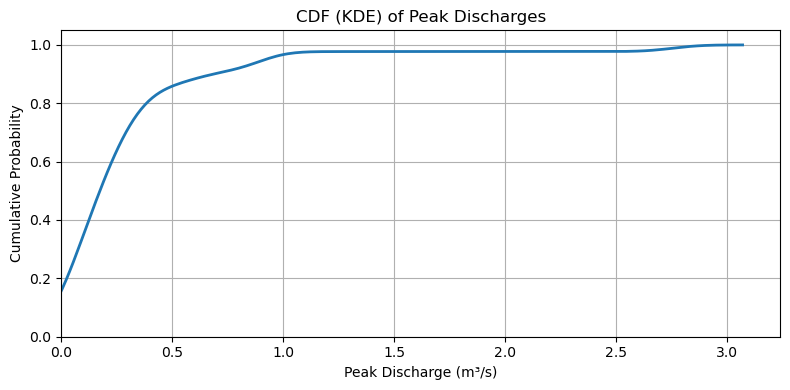

In [8]:
x = np.sort(flow_events['flow_peak_m3_s'].clip(lower=0))

plt.figure(figsize=(8, 4))
sns.kdeplot(x, cumulative=True, bw_adjust=0.5, linewidth=2)
plt.title("CDF (KDE) of Peak Discharges")
plt.xlabel("Peak Discharge (m³/s)")
plt.ylabel("Cumulative Probability")
plt.xlim(left=0)  # This ensures no negative X-values on plot
plt.grid(True)
plt.tight_layout()
plt.show()


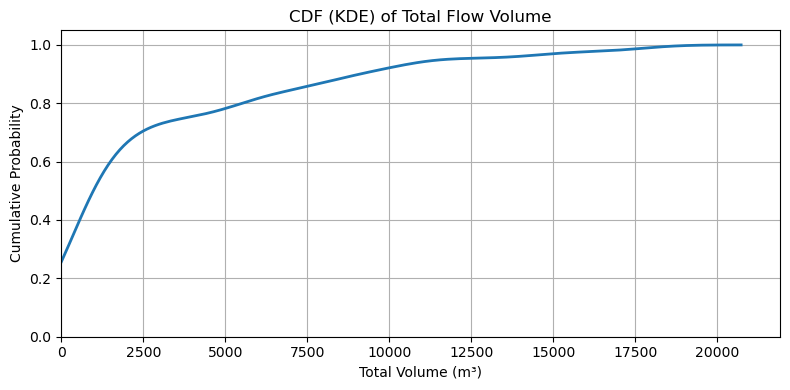

In [9]:
# Sort data
x = np.sort(flow_events['flow_total_volume_m3'])

# Estimate CDF via KDE
plt.figure(figsize=(8, 4))
sns.kdeplot(x, cumulative=True, bw_adjust=0.5, linewidth=2)
plt.title("CDF (KDE) of Total Flow Volume")
plt.xlabel("Total Volume (m³)")
plt.ylabel("Cumulative Probability")
plt.xlim(left=0)  # This ensures no negative X-values on plot
plt.grid(True)
plt.tight_layout()
plt.show()


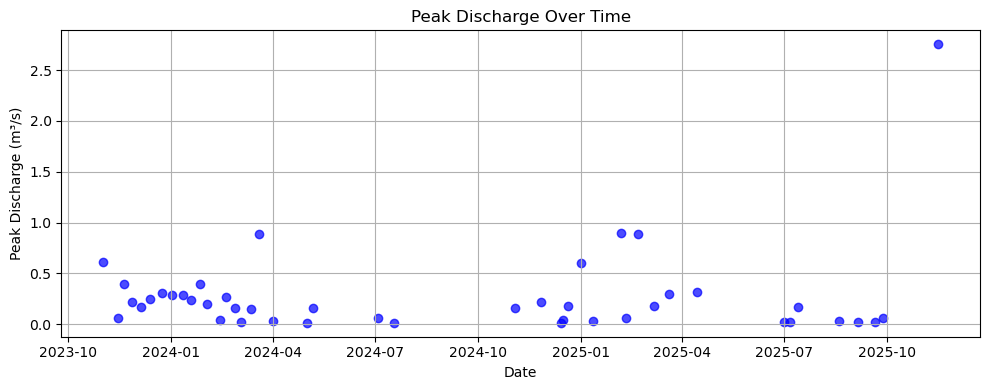

In [10]:
# Combine peak date + time into datetime
flow_events['peak_datetime'] = pd.to_datetime(
    flow_events['flow_peak_date'].astype(str) + ' ' + flow_events['flow_peak_time'].astype(str)
)

plt.figure(figsize=(10, 4))
plt.scatter(flow_events['peak_datetime'], flow_events['flow_peak_m3_s'], color='blue', alpha=0.7)
plt.title("Peak Discharge Over Time")
plt.xlabel("Date")
plt.ylabel("Peak Discharge (m³/s)")
plt.grid(True)
plt.tight_layout()
plt.show()

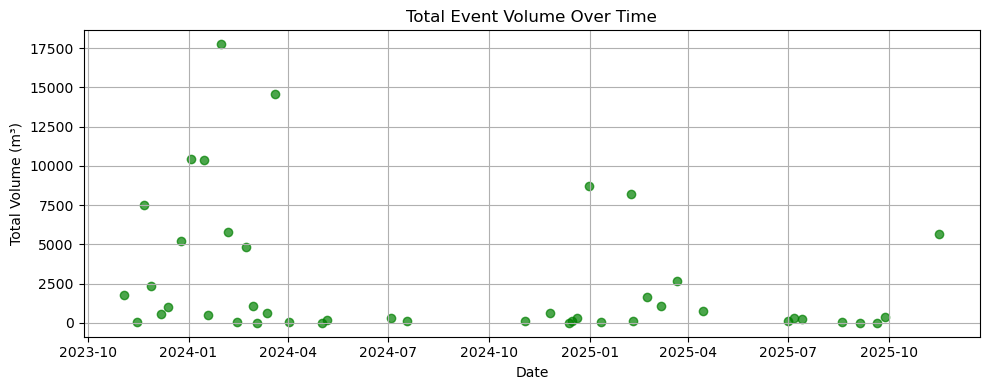

In [11]:
# Combine end date + time into datetime
flow_events['end_datetime'] = pd.to_datetime(
    flow_events['flow_end_date'].astype(str) + ' ' + flow_events['flow_end_time'].astype(str)
)

plt.figure(figsize=(10, 4))
plt.scatter(flow_events['end_datetime'], flow_events['flow_total_volume_m3'], color='green', alpha=0.7)
plt.title("Total Event Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Total Volume (m³)")
plt.grid(True)
plt.tight_layout()
plt.show()


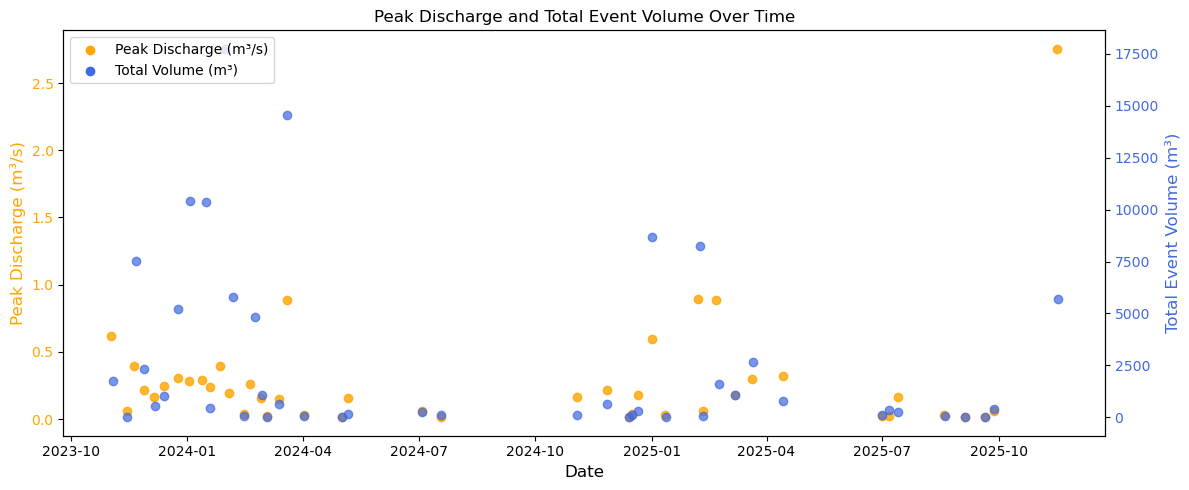

In [12]:
import matplotlib.pyplot as plt

# ודא שיש לך את שני העמודות: peak_datetime, end_datetime
# ואם לא, הרץ שוב את קטע יצירת העמודות

fig, ax1 = plt.subplots(figsize=(12, 5))

# ציר שמאל: שיא הספיקה (כתום)
color_peak = 'orange'
ax1.scatter(flow_events['peak_datetime'], flow_events['flow_peak_m3_s'],
            color=color_peak, alpha=0.8, label="Peak Discharge (m³/s)")
ax1.set_ylabel("Peak Discharge (m³/s)", color=color_peak, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_peak)
ax1.set_xlabel("Date", fontsize=12)

# ציר ימין: נפח נגר (כחול)
ax2 = ax1.twinx()
color_vol = 'royalblue'
ax2.scatter(flow_events['end_datetime'], flow_events['flow_total_volume_m3'],
            color=color_vol, alpha=0.7, label="Total Volume (m³)")
ax2.set_ylabel("Total Event Volume (m³)", color=color_vol, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_vol)

# כותרת ואסתטיקה
plt.title("Peak Discharge and Total Event Volume Over Time")
fig.tight_layout()

# אגדה (לשני הסדרות)
lns1 = ax1.scatter([], [], color=color_peak, label="Peak Discharge (m³/s)")
lns2 = ax2.scatter([], [], color=color_vol, label="Total Volume (m³)")
plt.legend([lns1, lns2], ["Peak Discharge (m³/s)", "Total Volume (m³)"], loc="upper left")

plt.show()


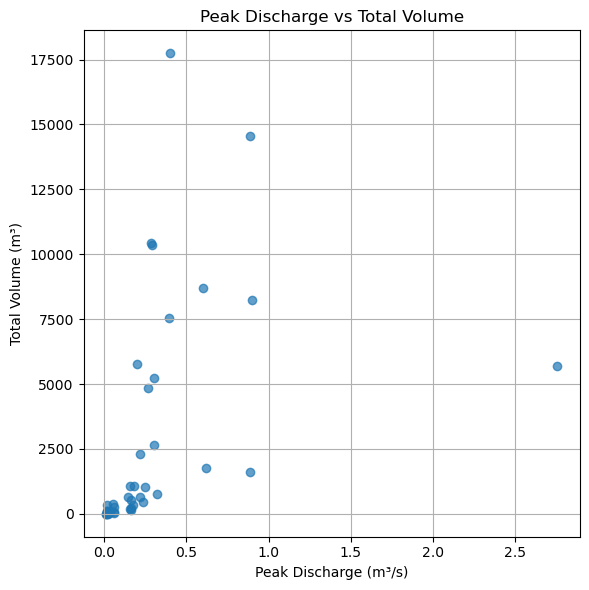

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(flow_events['flow_peak_m3_s'], flow_events['flow_total_volume_m3'], alpha=0.7)
plt.title("Peak Discharge vs Total Volume")
plt.xlabel("Peak Discharge (m³/s)")
plt.ylabel("Total Volume (m³)")
plt.grid(True)
plt.tight_layout()
plt.show()


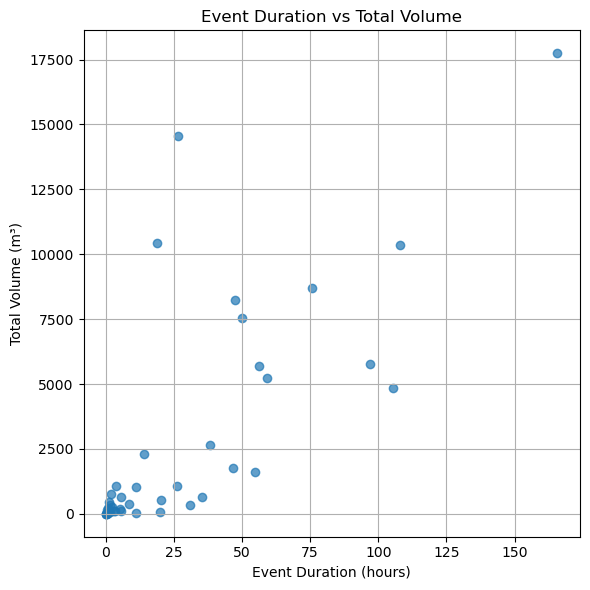

In [14]:
# Compute event duration
start_dt = pd.to_datetime(flow_events['flow_start_date'].astype(str) + ' ' + flow_events['flow_start_time'].astype(str))
end_dt = pd.to_datetime(flow_events['flow_end_date'].astype(str) + ' ' + flow_events['flow_end_time'].astype(str))
flow_events['event_duration_hours'] = (end_dt - start_dt).dt.total_seconds() / 3600

plt.figure(figsize=(6, 6))
plt.scatter(flow_events['event_duration_hours'], flow_events['flow_total_volume_m3'], alpha=0.7)
plt.xlabel("Event Duration (hours)")
plt.ylabel("Total Volume (m³)")
plt.title("Event Duration vs Total Volume")
plt.grid(True)
plt.tight_layout()
plt.show()


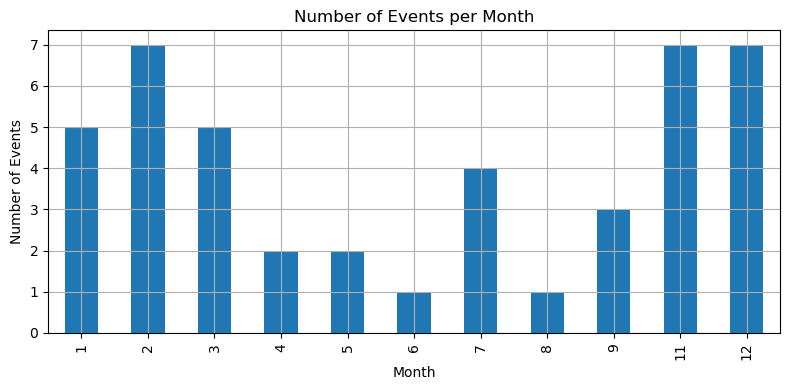

In [15]:
flow_events['month'] = pd.to_datetime(flow_events['flow_start_date']).dt.month
monthly_counts = flow_events['month'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
monthly_counts.plot(kind='bar')
plt.title("Number of Events per Month")
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.grid(True)
plt.tight_layout()
plt.show()


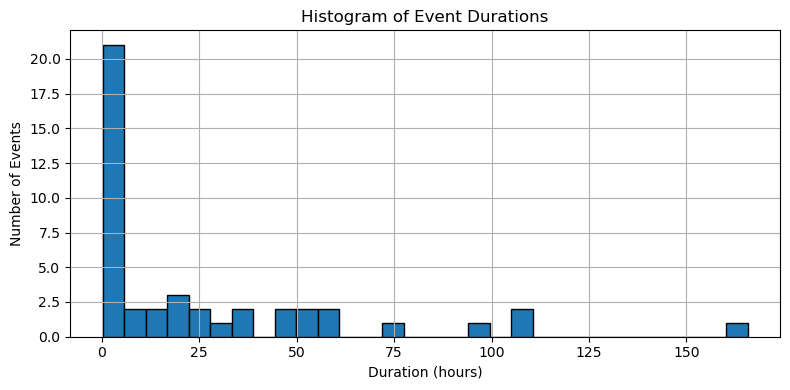

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(flow_events['event_duration_hours'], bins=30, edgecolor='black')
plt.title("Histogram of Event Durations")
plt.xlabel("Duration (hours)")
plt.ylabel("Number of Events")
plt.grid(True)
plt.tight_layout()
plt.show()


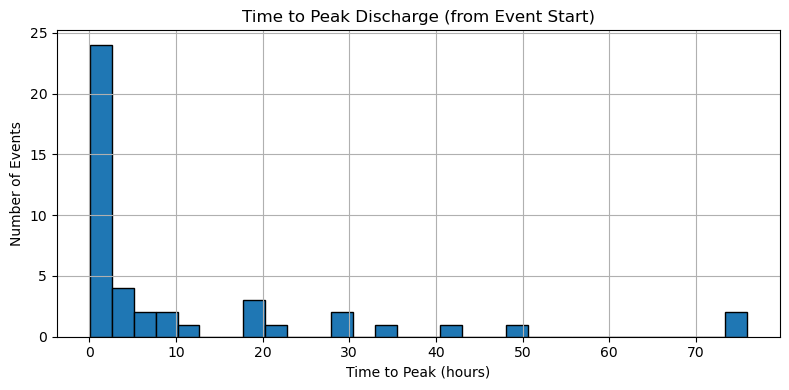

In [17]:
peak_dt = pd.to_datetime(flow_events['flow_peak_date'].astype(str) + ' ' + flow_events['flow_peak_time'].astype(str))
start_dt = pd.to_datetime(flow_events['flow_start_date'].astype(str) + ' ' + flow_events['flow_start_time'].astype(str))
flow_events['time_to_peak_hours'] = (peak_dt - start_dt).dt.total_seconds() / 3600

plt.figure(figsize=(8, 4))
plt.hist(flow_events['time_to_peak_hours'], bins=30, edgecolor='black')
plt.title("Time to Peak Discharge (from Event Start)")
plt.xlabel("Time to Peak (hours)")
plt.ylabel("Number of Events")
plt.grid(True)
plt.tight_layout()
plt.show()


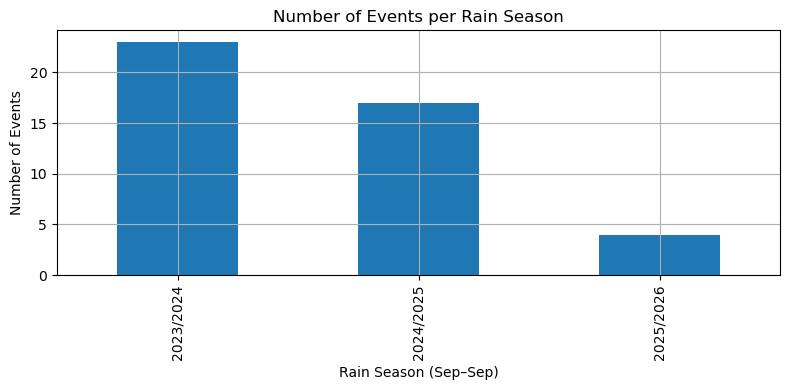

In [18]:
# Create rain season year (e.g., 2023/2024)
start_dates = pd.to_datetime(flow_events['flow_start_date'])
flow_events['rain_season'] = start_dates.apply(
    lambda d: f"{d.year}/{d.year + 1}" if d.month >= 9 else f"{d.year - 1}/{d.year}"
)

# Count events per rain season
season_counts = flow_events['rain_season'].value_counts().sort_index()

# Plot
plt.figure(figsize=(8, 4))
season_counts.plot(kind='bar')
plt.title("Number of Events per Rain Season")
plt.xlabel("Rain Season (Sep–Sep)")
plt.ylabel("Number of Events")
plt.grid(True)
plt.tight_layout()
plt.show()
